[nltk_data] Downloading package wordnet to /root/nltk_data...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Using device: cuda


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.552100,0.438778,0.800972
2,0.346200,0.354952,0.875203
3,0.218800,0.430243,0.897569
4,0.165000,0.474338,0.897245
5,0.112500,0.501822,0.913452
6,0.079100,0.561910,0.915721
7,0.057800,0.592740,0.918963
8,0.038200,0.585685,0.920908
9,0.028500,0.633746,0.919611
10,0.021300,0.662732,0.921232



✅ Test Accuracy: 0.9212317666126418

✅ Classification Report:
               precision    recall  f1-score   support

    Non-Hate       0.94      0.93      0.94      1873
        Hate       0.90      0.90      0.90      1212

    accuracy                           0.92      3085
   macro avg       0.92      0.92      0.92      3085
weighted avg       0.92      0.92      0.92      3085



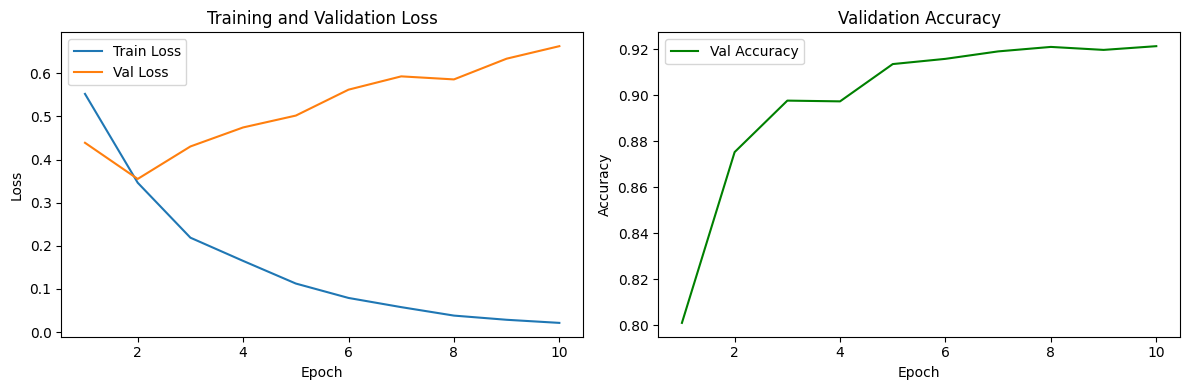

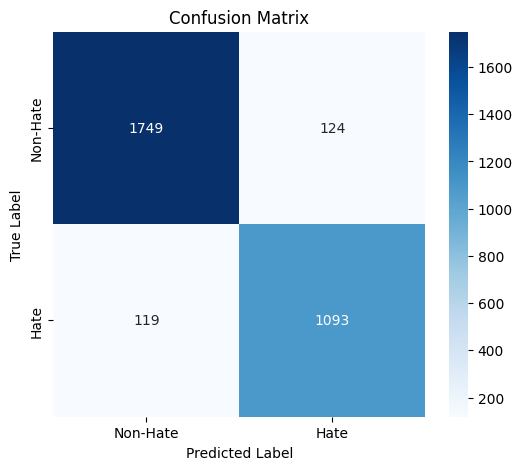

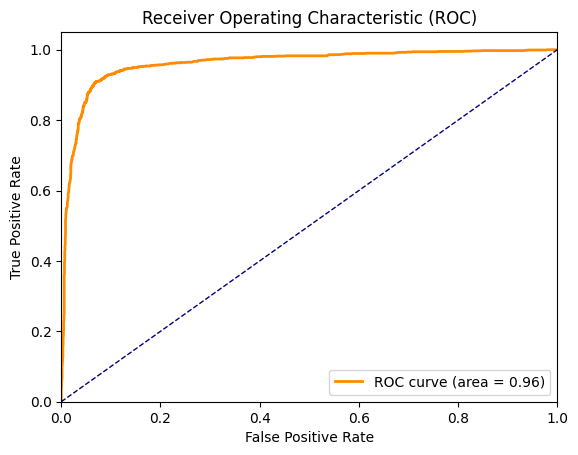

In [ ]:
# tuned_roberta_training_single_run.py
# ================== CLEAN SETUP ==================
import os, warnings, logging, re, random
os.environ["WANDB_DISABLED"] = "true"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

# ================== IMPORTS ==================
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import nltk
from nltk.corpus import wordnet
from transformers import (
    RobertaTokenizerFast,
    RobertaModel,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from torch.nn import CrossEntropyLoss
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download("wordnet")

# ================== TEXT CLEANING ==================
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()

# ================== AUGMENTATION ==================
def synonym_replacement(sentence, n=1):
    words = sentence.split()
    new_words = words.copy()
    candidates = [w for w in words if len(w) > 1 and len(wordnet.synsets(w)) > 0]
    random.shuffle(candidates)
    num_replaced = 0
    for w in candidates:
        synonyms = wordnet.synsets(w)
        synonym_words = [lemma.name().replace("_", " ")
                         for syn in synonyms
                         for lemma in syn.lemmas()
                         if lemma.name() != w]
        if synonym_words:
            synonym = random.choice(synonym_words)
            new_words = [synonym if token == w else token for token in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return " ".join(new_words)

def random_deletion(sentence, p=0.1):
    words = sentence.split()
    if len(words) == 1:
        return sentence
    new_words = [w for w in words if random.uniform(0, 1) > p]
    if not new_words:
        return random.choice(words)
    return " ".join(new_words)

def random_swap(sentence, n_swaps=1):
    words = sentence.split()
    if len(words) < 2:
        return sentence
    for _ in range(n_swaps):
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
    return " ".join(words)

def random_insertion(sentence, n_insert=1):
    words = sentence.split()
    for _ in range(n_insert):
        candidates = [w for w in words if len(wordnet.synsets(w)) > 0]
        if not candidates:
            break
        word_to_replace = random.choice(candidates)
        synonyms = wordnet.synsets(word_to_replace)
        synonym_words = [
            lemma.name().replace("_", " ")
            for syn in synonyms
            for lemma in syn.lemmas()
            if lemma.name() != word_to_replace
        ]
        if synonym_words:
            insert_word = random.choice(synonym_words)
            pos = random.randrange(len(words) + 1)
            words.insert(pos, insert_word)
    return " ".join(words)

def augment_text(text):
    p = random.random()
    if p < 0.35:
        return synonym_replacement(text, n=1)
    elif p < 0.6:
        return random_deletion(text, p=0.15)
    elif p < 0.8:
        return random_swap(text, n_swaps=1)
    else:
        return random_insertion(text, n_insert=1)

# ================== LOAD DATA ==================
df = pd.read_csv("Dataset_1_2_3_4.csv")

if df["label"].dtype == "object":
    label_mapping = {"Non-Hate": 0, "Hate": 1}
    df["label"] = df["label"].map(label_mapping)

df["label"] = df["label"].astype(int)
df["text"] = df["text"].astype(str).apply(clean_text)

# ================== STRONG AUGMENTATION ==================
AUGMENT_FACTOR = 2
AUGMENT_PROB = 0.4
augmented_rows = []
for text, label in zip(df["text"], df["label"]):
    if random.random() < AUGMENT_PROB:
        for _ in range(AUGMENT_FACTOR):
            augmented_text = augment_text(text)
            augmented_rows.append({"text": augmented_text, "label": label})

df_aug = pd.DataFrame(augmented_rows)
if not df_aug.empty:
    df = pd.concat([df, df_aug]).reset_index(drop=True)

df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)

# ================== SPLIT DATASET ==================
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

# ================== CLASS WEIGHTS ==================
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float)

# ================== TOKENIZER ==================
MODEL_NAME = "roberta-base"
tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)

# ================== CUSTOM DATASET ==================
class TextDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=tokenizer, max_len=192):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# ================== CUSTOM CLASSIFIER ==================
class CustomRobertaClassifier(nn.Module):
    def __init__(self, base_model_name, num_labels=2, hidden_dropout_prob=0.2, intermediate_dim=None, activation="gelu"):
        super().__init__()
        self.base = RobertaModel.from_pretrained(base_model_name)
        base_hidden = self.base.config.hidden_size
        if intermediate_dim is None:
            intermediate_dim = base_hidden // 2
        self.dropout = nn.Dropout(hidden_dropout_prob)
        self.dense = nn.Linear(base_hidden, intermediate_dim)
        if activation == "gelu":
            self.act = nn.GELU()
        elif activation == "relu":
            self.act = nn.ReLU()
        elif activation == "leaky":
            self.act = nn.LeakyReLU()
        else:
            self.act = nn.GELU()
        self.out_proj = nn.Linear(intermediate_dim, num_labels)

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.base(input_ids=input_ids, attention_mask=attention_mask)
        # Use mean pooling
        pooled = outputs.last_hidden_state.mean(dim=1)
        x = self.dropout(pooled)
        x = self.dense(x)
        x = self.act(x)
        logits = self.out_proj(x)
        loss = None
        if labels is not None:
            loss_fct = CrossEntropyLoss(weight=class_weights.to(logits.device))
            loss = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))
            return {"loss": loss, "logits": logits}
        return {"logits": logits}

# ================== PREPARE DATASETS ==================
train_dataset = TextDataset(train_texts, train_labels)
test_dataset  = TextDataset(test_texts, test_labels)

# ================== DEVICE INFO ==================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================== TRAINING ==================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

model = CustomRobertaClassifier(
    base_model_name=MODEL_NAME,
    num_labels=2,
    hidden_dropout_prob=0.2,
    intermediate_dim=384,
    activation="gelu"
).to(device)

training_args = TrainingArguments(
    output_dir="./results_roberta_tuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    warmup_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    save_total_limit=2,
    seed=42,
    report_to="none"
)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs, labels=labels)
        loss = outputs["loss"] if isinstance(outputs, dict) else outputs[0]
        return (loss, outputs) if return_outputs else loss

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# ================== TRAIN ==================
trainer.train()

# ================== EVALUATE ==================
predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(axis=-1)

print("\n✅ Test Accuracy:", accuracy_score(test_labels, y_pred))
print("\n✅ Classification Report:\n", classification_report(test_labels, y_pred, target_names=["Non-Hate", "Hate"]))

# ================== VISUALIZATIONS ==================

# 1. Training and validation loss / accuracy plots
log_history = trainer.state.log_history

train_loss = [x["loss"] for x in log_history if "loss" in x]
eval_loss = [x["eval_loss"] for x in log_history if "eval_loss" in x]
eval_acc = [x["eval_accuracy"] for x in log_history if "eval_accuracy" in x]

epochs_train_loss = list(range(1, len(train_loss) + 1))
epochs_eval_loss = list(range(1, len(eval_loss) + 1))
epochs_eval_acc = list(range(1, len(eval_acc) + 1))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_train_loss, train_loss, label="Train Loss")
plt.plot(epochs_eval_loss, eval_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_eval_acc, eval_acc, label="Val Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# 2. Confusion matrix
cm = confusion_matrix(test_labels, y_pred)
labels = ["Non-Hate", "Hate"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 3. ROC curve
from sklearn.preprocessing import label_binarize

# Convert predictions to probabilities and true labels to binary
probs = torch.softmax(torch.tensor(predictions.predictions), dim=1).numpy()[:, 1]
y_bin = label_binarize(test_labels, classes=[0, 1]).ravel()

fpr, tpr, thresholds = roc_curve(y_bin, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.show()
